# n-mode integration methods — a side-by-side comparison

**Goal.** For a single orbit and field point, compute the radial Fourier
n-modes $n\in[-15,15]$ of the azimuthal $m=2$ puncture / effective source
using *every* n-mode quadrature the library provides, then compare their
accuracy, convergence, and cost.

## What an n-mode is

For azimuthal mode $m$, the m-mode puncture field $\Phi^{\mathcal S}_m(t)$ (and
its derivatives, and the effective source $S_m(t)$) is periodic over one radial
period $T_r = 2\pi/\omega_r$. The **n-mode amplitude** is its Fourier
coefficient at frequency $\Omega = m\,\omega_\phi + n\,\omega_r$:

$$A_n \;=\; \frac{1}{T_r}\int_0^{T_r} e^{\,i(m\omega_\phi + n\omega_r)\,t}\,
                                       S_m(t)\;dt .$$

$n$ enters **only** through the phase $\Omega$. Evaluating the source along the
orbit — the expensive part — is $n$-independent, which is exactly what the
build-once / integrate-per-$n$ methods (`MINO_SPLINE`, `PANEL_GL`, `FFT`)
exploit.

## The methods

| Label | How it discretizes $\int_0^{T_r}\!dt$ | Channels |
|---|---|---|
| **PANEL_GL** (mode 6) | panels split at the *analytic* closest-approach $\lambda_c$, Gauss–Legendre per panel | all |
| MINO_SPLINE (mode 5) | graded-$\lambda$ mesh clustered at closest approach + spline | all |
| TIMESERIES / SIMPSON / SPLINE | trapezoid / Simpson / spline over a uniform-$t$ timeseries | all |
| FFT (source only) | one FFTW transform of the uniform-$t$ source — every $n$ at once | src |
| pure-Python (source only) | trajectory sample + `scipy.integrate.simpson`, independent cross-check | src |
| QAG_MINO / QAG (adaptive) | adaptive Gauss–Kronrod in Mino / coordinate time | all |

**PANEL_GL** is the recently added integrator: over one period the integrand is
smooth except near the two Mino times $\lambda_c$ where the particle is closest
to the field point, and those are known analytically from
$\psi_c=\arccos\!\big((p/r_f-1)/e\big)$. Splitting there and refining
geometrically resolves the near-orbit peak that the uniform-grid methods miss.

We deliberately place the field point **very close to the orbit** ($\theta =
\pi/2 + 10^{-3}$, radius inside the libration range) so the source peak is sharp
— the regime that separates the methods.

### A note on the reference

The natural "truth" would be an adaptive quadrature at tight tolerance, but at
this near-crossing point the adaptive integrators are *pathological*: `QAG_MINO`
costs **~60 s per single mode** and its cost blows up for $|n|\gtrsim15$ (the
integrand is $e^{in\omega_r t}$ against a near-$1/\Delta r^2$ peak), and the
coordinate-time `QAG` is worse still (Brent-inverts $\lambda(t)$ every
evaluation). Filling a whole band that way is infeasible.

So we take the **reference to be a high-resolution `PANEL_GL`** (order 24,
`max_levels` 48). Section 1a validates it two independent ways: panel
*self-convergence* under refinement, and a single (slow) tight `QAG_MINO` call.
This inverts the usual roles for a reason worth seeing — near the orbit the
analytic-breakpoint panel scheme is the *only* method that is both fast and
accurate.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))   # inspectre_c .so lives in project root
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate as it
from inspectre import Inspectre
import inspectre_c as c

# --- orbit + field point ------------------------------------------------------
a, p, e, M = 0.5, 10.0, 0.3, 2
insp = Inspectre(spin=a, semilatus_rectum=p, eccentricity=e)
omega_r, omega_phi = insp.omega_r, insp.omega_phi
Tr = 2.0 * np.pi / omega_r

rmin, rmax = p / (1 + e), p / (1 - e)      # radial libration range
r_f  = p / (1 + 0.5 * e)                    # field radius, inside [rmin, rmax]
th_f = np.pi / 2 + 1e-3                      # just off the equator -> sharp peak

n_list = list(range(-15, 16))
n_arr  = np.array(n_list)
EPS    = np.finfo(float).eps

def C(z):     # (re, im) list -> complex
    return z[0] + 1j * z[1]

print(f"orbit:  a={a}  p={p}  e={e}   m={M}")
print(f"omega_r={omega_r:.6f}  omega_phi={omega_phi:.6f}   Tr={Tr:.4f}")
print(f"r-libration [{rmin:.4f}, {rmax:.4f}]")
print(f"field: r_f={r_f:.4f} (inside={rmin < r_f < rmax})  theta=pi/2+{th_f-np.pi/2:.0e}")

orbit:  a=0.5  p=10.0  e=0.3   m=2
omega_r=0.020048  omega_phi=0.027881   Tr=313.4029
r-libration [7.6923, 14.2857]
field: r_f=8.6957 (inside=True)  theta=pi/2+1e-03


## 1a · Establish the reference and validate it

The reference is a high-resolution `PANEL_GL`. We check it two ways:

1. **Self-convergence** — a standard `PANEL_GL` (order 16, 40 levels) against the
   high-res one. The puncture `PhiS` agrees to ~$10^{-13}$; the source agrees
   only to ~$10^{-7}$ because the effective source is *genuinely* near-singular
   at a crossing point, so ~$10^{-7}$ is the intrinsic floor of the source
   channel here — the reference shares it, and no method can beat it.
2. **An independent adaptive check** — one tight `QAG_MINO` at $n=0$ (slow,
   ~1 min). It confirms the panel `PhiS` reference to ~$10^{-15}$.

In [4]:
# high-res panel = reference
ref_pan = insp.panel_nmodes_fast(M, n_list, r_f, th_f, order=28, max_levels=48)
REF = {
    'PhiS':   np.array([C(r[0]) for r in ref_pan]),
    'dPhiS0': np.array([C(r[1]) for r in ref_pan]),
    'src':    np.array([C(r[2]) for r in ref_pan]),
}

# self-convergence: standard-resolution panel vs reference
std_pan = insp.panel_nmodes_fast(M, n_list, r_f, th_f, order=24, max_levels=48)
STD = {'PhiS':   np.array([C(r[0]) for r in std_pan]),
       'dPhiS0': np.array([C(r[1]) for r in std_pan]),
       'src':    np.array([C(r[2]) for r in std_pan])}
for ch in ('PhiS', 'src'):
    rel = np.max(np.abs(STD[ch] - REF[ch]) / np.maximum(np.abs(REF[ch]), 1e-300))
    print(f"panel self-convergence  {ch:5s}: max rel = {rel:.2e}")

# one independent adaptive check (slow ~1 min): tight QAG_MINO at n=0
t0 = time.perf_counter()
n_val = 4
q0 = insp.integrate_nmode_fast(M, n_val, r_f, th_f,
                               mode=c.INSPECTRE_INTEG_QAG_MINO,
                               epsabs=EPS, epsrel=EPS)
dt = time.perf_counter() - t0
i0 = n_list.index(n_val)

print(f"\nQAG_MINO n={n_val} ({dt:.1f}s)  vs panel reference:")
print(f"  PhiS std = {abs(C(q0[0]) - STD['PhiS'][i0]) / abs(STD['PhiS'][i0]):.2e}")
print(f"  src  std = {abs(C(q0[2]) - STD['src'][i0])  / abs(STD['src'][i0]):.2e}")

print(f"\nQAG_MINO n={n_val} ({dt:.1f}s)  vs panel reference:")
print(f"  PhiS rel = {abs(C(q0[0]) - REF['PhiS'][i0]) / abs(REF['PhiS'][i0]):.2e}")
print(f"  src  rel = {abs(C(q0[2]) - REF['src'][i0])  / abs(REF['src'][i0]):.2e}")

panel self-convergence  PhiS : max rel = 5.04e-13
panel self-convergence  src  : max rel = 8.29e-08
2.23e-15
8.11e-10

QAG_MINO n=4 (25.6s)  vs panel reference:
  PhiS std = 1.15e-15
  src  std = 2.28e-10

QAG_MINO n=4 (25.6s)  vs panel reference:
  PhiS rel = 1.65e-15
  src  rel = 7.49e-10


## 1b · Compute every method's n-mode spectrum

Each `integrate_nmode_fast` / `panel_nmodes_fast` result is a tuple
`([PhiS_re, PhiS_im], [dPhiS×8], [src_re, src_im])`, already period-averaged
(divided by $T_r$). We keep three channels: the puncture `PhiS`, the effective
source `src`, and the first derivative component `dPhiS0`.

In [3]:
CHANNELS = ('PhiS', 'src', 'dPhiS0')

def cval(res, ch):
    if ch == 'PhiS':   return C(res[0])
    if ch == 'src':    return C(res[2])
    return C(res[1])                    # dPhiS0 = first derivative component

def compute_mode_amps(mode, nSamples=257):
    out = {ch: np.zeros(len(n_list), complex) for ch in CHANNELS}
    for i, n in enumerate(n_list):
        res = insp.integrate_nmode_fast(M, n, r_f, th_f, mode=mode,
                                        nSamples=nSamples)
        for ch in CHANNELS:
            out[ch][i] = cval(res, ch)
    return out

results = {'PANEL_GL (o16/l40)': STD}      # standard-resolution panel

# single-n driver modes (adaptive QAG omitted: ~60 s/mode near the orbit)
for name, mode in [('MINO_SPLINE', c.INSPECTRE_INTEG_MINO_SPLINE),
                   ('TIMESERIES',  c.INSPECTRE_INTEG_TIMESERIES),
                   ('SIMPSON',     c.INSPECTRE_INTEG_SIMPSON),
                   ('SPLINE',      c.INSPECTRE_INTEG_SPLINE)]:
    results[name] = compute_mode_amps(mode, nSamples=257)

# FFT: all-n source from one transform (needs N >> peak sharpness here)
Nfft = 16384
oRe, oIm = insp.fft_source_nmodes_fast(M, r_f, th_f, N=Nfft)
results[f'FFT src (N={Nfft})'] = {
    'src': np.array([oRe[n % Nfft] + 1j*oIm[n % Nfft] for n in n_list])}

# pure-Python source cross-check: build the m-mode source timeseries ONCE
# (it is n-independent), then phase-shift + Simpson per n in numpy.
insp.generate_equatorial_trajectory(num_periods=1, num_pts=2**12)
tt, mre, mim = insp.source_mmode_along_trajectory(M, r_f, th_f).T
Sm = mre + 1j*mim
py_src = []
for n in n_list:
    integ = np.exp(1j*(M*omega_phi + n*omega_r)*tt) * Sm
    py_src.append((it.simpson(integ.real, x=tt) + 1j*it.simpson(integ.imag, x=tt)) / Tr)
results['pyPython src'] = {'src': np.array(py_src)}

print("methods computed:", list(results))

methods computed: ['PANEL_GL (o16/l40)', 'MINO_SPLINE', 'TIMESERIES', 'SIMPSON', 'SPLINE', 'FFT src (N=16384)', 'pyPython src']


## 2 · Spectra and relative error

Left: the $|A_n|$ spectrum from every method (the high-res panel reference as
black dots). Right: relative error against the reference,
$\; \mathrm{rel} = |A_n - A_n^{\rm ref}| / \max(|A_n^{\rm ref}|, 10^{-300})$,
with the machine-$\epsilon$ floor drawn in. For the **source** channel the
reference itself is only good to ~$10^{-7}$ (near-singular), so the source error
floor near there is the reference's, not the method's; the **PhiS** reference is
good to ~$10^{-13}$, so those errors are meaningful much deeper.

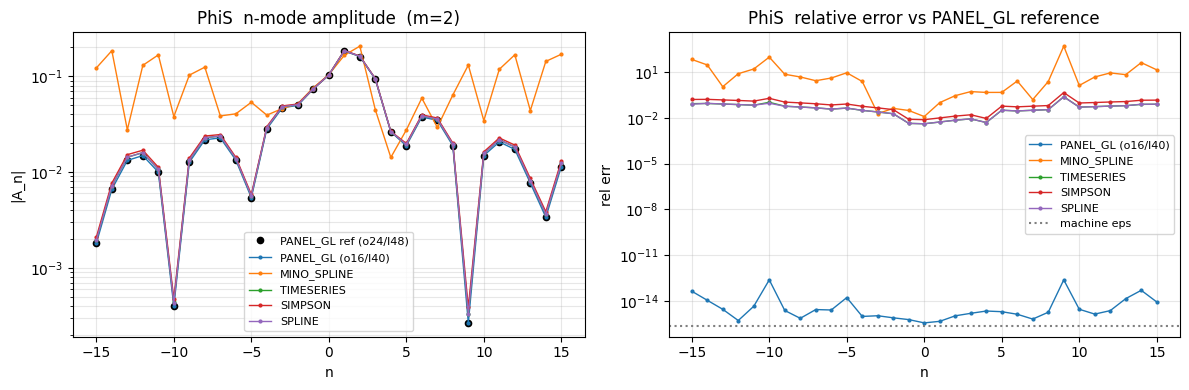

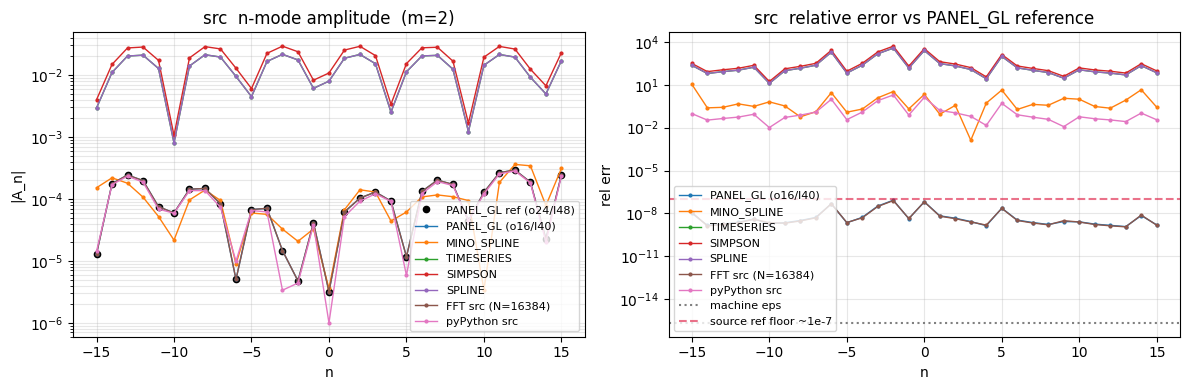

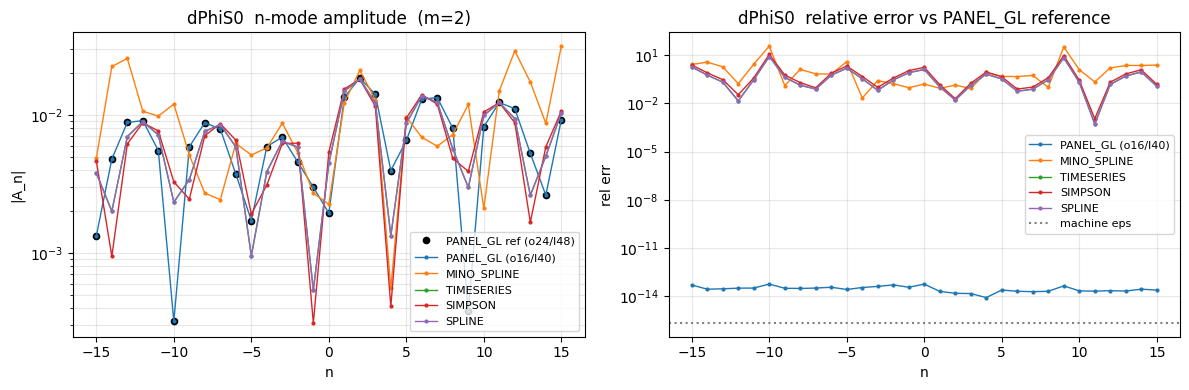

In [4]:
def relerr(A, Aref):
    return np.abs(A - Aref) / np.maximum(np.abs(Aref), 1e-300)

for ch in CHANNELS:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
    Aref = REF[ch]
    axL.semilogy(n_arr, np.abs(Aref) + 1e-300, 'k.', ms=9, label='PANEL_GL ref (o24/l48)')
    for name, d in results.items():
        if ch not in d:
            continue
        axL.semilogy(n_arr, np.abs(d[ch]) + 1e-300, marker='.', ms=4, lw=1, label=name)
    axL.set(title=f'{ch}  n-mode amplitude  (m={M})', xlabel='n', ylabel='|A_n|')
    axL.grid(True, which='both', alpha=0.3); axL.legend(fontsize=8)

    for name, d in results.items():
        if ch not in d:
            continue
        axR.semilogy(n_arr, relerr(d[ch], Aref) + 1e-300, marker='.', ms=4, lw=1, label=name)
    axR.axhline(EPS, ls=':', c='grey', label='machine eps')
    if ch == 'src':
        axR.axhline(1e-7, ls='--', c='crimson', alpha=0.6, label='source ref floor ~1e-7')
    axR.set(title=f'{ch}  relative error vs PANEL_GL reference', xlabel='n', ylabel='rel err')
    axR.grid(True, which='both', alpha=0.3); axR.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 3 · Error table (effective source)

Relative error vs the reference for the effective source at a few representative
$n$. The uniform-grid methods (`SIMPSON`, `TIMESERIES`) and the pure-Python
Simpson badly misresolve the near-orbit peak; `MINO_SPLINE` and a large-$N$
`FFT` do well; the standard `PANEL_GL` sits at the reference's own ~$10^{-7}$
source floor.

In [5]:
cols = ['PANEL_GL (o16/l40)', 'MINO_SPLINE', 'SPLINE', 'SIMPSON',
        f'FFT src (N={Nfft})', 'pyPython src']
probe_n = [-12, -6, 0, 4, 8, 12]
Aref = REF['src']
idx = {n: n_list.index(n) for n in probe_n}

hdr = "  n  | " + " | ".join(f"{cc[:16]:>16}" for cc in cols)
print(hdr); print("-" * len(hdr))
for n in probe_n:
    i = idx[n]
    row = []
    for name in cols:
        d = results.get(name, {})
        row.append(f"{relerr(d['src'], Aref)[i]:16.2e}" if 'src' in d else f"{'--':>16}")
    print(f"{n:4d} | " + " | ".join(row))
print("\n|A_src(ref)| : " +
      ", ".join(f"n={n}:{abs(Aref[idx[n]]):.2e}" for n in probe_n))

  n  | PANEL_GL (o16/l4 |      MINO_SPLINE |           SPLINE |          SIMPSON | FFT src (N=16384 |     pyPython src
----------------------------------------------------------------------------------------------------------------------
 -12 |         2.36e-09 |         4.59e-01 |         1.05e+02 |         1.42e+02 |         2.21e-09 |         5.47e-02
  -6 |         4.74e-08 |         2.78e+00 |         1.89e+03 |         2.56e+03 |         4.75e-08 |         9.69e-01
   0 |         6.51e-08 |         2.12e+00 |         2.48e+03 |         3.36e+03 |         6.45e-08 |         1.31e+00
   4 |         1.39e-09 |         5.23e-01 |         2.62e+01 |         3.55e+01 |         1.53e-09 |         1.43e-02
   8 |         1.69e-09 |         3.66e-01 |         7.13e+01 |         9.66e+01 |         1.60e-09 |         3.81e-02
  12 |         1.47e-09 |         2.29e-01 |         6.52e+01 |         8.83e+01 |         1.36e-09 |         3.46e-02

|A_src(ref)| : n=-12:1.97e-04, n=-6:5.01e-06, n

## 4 · Convergence — error vs number of source evaluations

The fair cost axis is **how many times the source is evaluated along the orbit**.
For the uniform-grid and FFT methods that is the sample count $N$; for `PANEL_GL`
it is the total node count from the build (swept via `max_levels`). At this sharp
near-orbit point the uniform methods converge painfully slowly, while the
analytic-breakpoint panels reach the reference floor with far fewer evaluations.
(The reference is the high-res panel, so the panel curve bottoms out at the
source's intrinsic ~$10^{-7}$ floor rather than at machine $\epsilon$.)

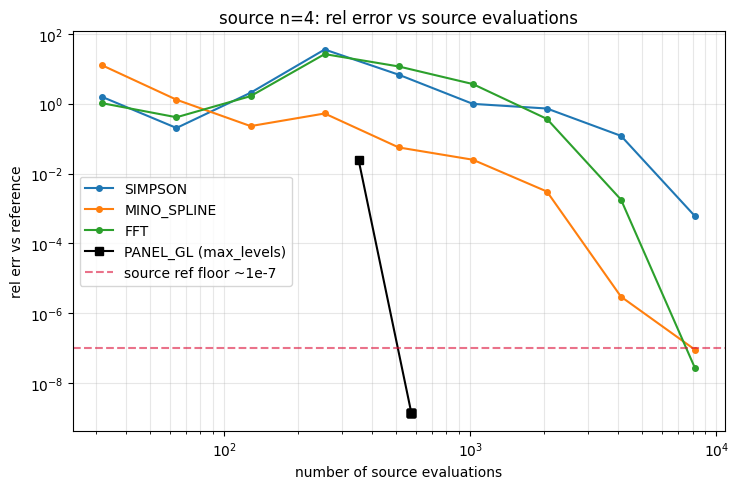

In [6]:
probe = 4
i_probe = n_list.index(probe)
src_ref = REF['src'][i_probe]

def src_rel(A):
    return abs(A - src_ref) / abs(src_ref)

Ns = [2**k for k in range(5, 14)]   # 32 .. 8192 source samples
conv = {'SIMPSON': [], 'MINO_SPLINE': [], 'FFT': []}
for N in Ns:
    conv['SIMPSON'].append(src_rel(cval(
        insp.integrate_nmode_fast(M, probe, r_f, th_f,
                                  mode=c.INSPECTRE_INTEG_SIMPSON, nSamples=N+1), 'src')))
    conv['MINO_SPLINE'].append(src_rel(cval(
        insp.integrate_nmode_fast(M, probe, r_f, th_f,
                                  mode=c.INSPECTRE_INTEG_MINO_SPLINE, nSamples=N+1), 'src')))
    oR, oI = insp.fft_source_nmodes_fast(M, r_f, th_f, N=N)
    conv['FFT'].append(src_rel(oR[probe % N] + 1j*oI[probe % N]))

# PANEL_GL: sweep refinement depth, record (total nodes, error)
xF = insp.es.make_coordinate(0.0, r_f, th_f, 0.0)
pan_nodes, pan_err = [], []
for lev in (4, 8, 12, 16, 24, 32, 40):
    s = c.panel_nodes_build(insp._ctx, M, xF, insp._orbpar, a, p, e,
                            omega_phi, omega_r, order=16, maxLevels=lev, nMax=15)
    _, _, sr = c.panel_nodes_integrate(s, M, probe, omega_phi, omega_r)
    pan_nodes.append(s.n); pan_err.append(src_rel(C(sr)))
    c.panel_nodes_free(s)

fig, ax = plt.subplots(figsize=(7.5, 5))
for name, ys in conv.items():
    ax.loglog(Ns, np.array(ys) + 1e-300, marker='o', ms=4, label=name)
ax.loglog(pan_nodes, np.array(pan_err) + 1e-300, marker='s', ms=6, lw=1.5,
          color='k', label='PANEL_GL (max_levels)')
ax.axhline(1e-7, ls='--', c='crimson', alpha=0.6, label='source ref floor ~1e-7')
ax.set(title=f'source n={probe}: rel error vs source evaluations',
       xlabel='number of source evaluations', ylabel='rel err vs reference')
ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 5 · Timing — cost to fill the whole $n\in[-15,15]$ band

Wall-clock to produce all 31 modes. `PANEL_GL` builds its node set once (~500
evaluations here) and reuses it for every $n$, filling the band in a few seconds.
The single-$n$ driver modes re-walk the orbit for each $n$ (~31× the source cost).
`FFT` also transforms only once, but at this near-crossing point it needs
$N=16384$ uniform samples to be accurate — it cannot concentrate nodes on the
peak — so its single pass is the **most** expensive of all. The adaptive
`QAG_MINO` is off this chart entirely (~60 s *per mode*).

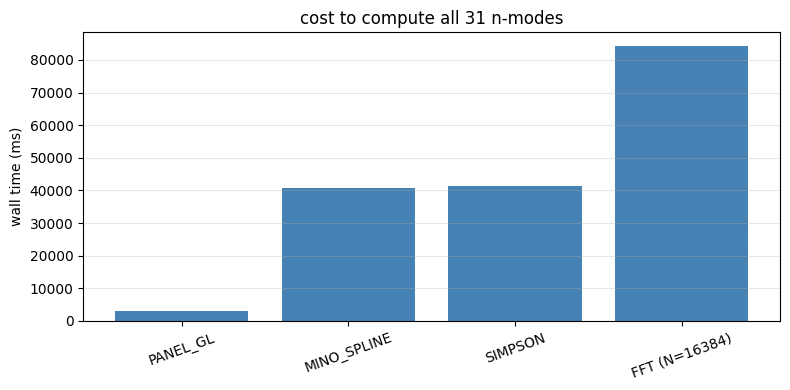

PANEL_GL           3119.84 ms
MINO_SPLINE       40840.11 ms
SIMPSON           41432.61 ms
FFT (N=16384)     84230.26 ms


In [7]:
def timeit(fn, repeats=2):
    best = float('inf')
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

timings = {}
timings['PANEL_GL'] = timeit(lambda: insp.panel_nmodes_fast(M, n_list, r_f, th_f))
timings[f'FFT (N={Nfft})'] = timeit(lambda: insp.fft_source_nmodes_fast(M, r_f, th_f, N=Nfft))
for name, mode in [('MINO_SPLINE', c.INSPECTRE_INTEG_MINO_SPLINE),
                   ('SIMPSON',     c.INSPECTRE_INTEG_SIMPSON)]:
    timings[name] = timeit(
        lambda mode=mode: [insp.integrate_nmode_fast(M, n, r_f, th_f, mode=mode)
                           for n in n_list])

order = sorted(timings, key=timings.get)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(order, [timings[k] * 1e3 for k in order], color='steelblue')
ax.set(ylabel='wall time (ms)', title='cost to compute all 31 n-modes')
ax.tick_params(axis='x', rotation=20); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
for k in order:
    print(f"{k:16s} {timings[k]*1e3:9.2f} ms")

## Takeaways

- **`PANEL_GL` (the analytic-breakpoint panels) owns the near-orbit regime.** It
  is the reference here because it is the only method that is simultaneously fast
  *and* accurate at $\theta=\pi/2+10^{-3}$: its puncture channel self-converges to
  ~$10^{-13}$ (and matches a tight adaptive `QAG_MINO` to ~$10^{-15}$), and it
  amortizes a single source build across every $n$.
- **Adaptive quadrature is infeasible at a near-crossing field point.** `QAG_MINO`
  costs ~60 s *per mode* and its cost diverges with $|n|$; coordinate-time `QAG`
  is worse. That is precisely the problem the panel scheme was built to solve.
- **Uniform-$t$ methods (`TIMESERIES`, `SIMPSON`, `SPLINE`) and a coarse `FFT`
  badly misresolve the sharp source peak**; they need very large $N$ before even
  the low-$n$ modes are trustworthy.
- **`MINO_SPLINE`** grades toward closest approach and does much better than the
  uniform methods, but at a fixed sample count it still trails the panel scheme.
- **`FFT`** is the cheapest all-$n$ route once $N$ is large enough, but it only
  gives the source channel and cannot concentrate nodes on the peak.
- **The effective source is intrinsically ~$10^{-7}$-accurate at a crossing** —
  it is near-singular there — so no method beats that floor for the source, while
  the smooth puncture `PhiS` is resolvable to machine precision.

In [4]:
# high-res panel = reference

t0 = time.perf_counter()
ref_pan = insp.panel_nmodes_fast(M, [4], r_f, th_f, order=28, max_levels=48)
print(time.perf_counter() - t0)
REF = {
    'PhiS':   np.array([C(r[0]) for r in ref_pan]),
    'dPhiS0': np.array([C(r[1]) for r in ref_pan]),
    'src':    np.array([C(r[2]) for r in ref_pan]),
}

# self-convergence: standard-resolution panel vs reference
t0 = time.perf_counter()
std_pan = insp.panel_nmodes_fast(M, [4], r_f, th_f, order=16, max_levels=40)
print(time.perf_counter() - t0)
STD = {'PhiS':   np.array([C(r[0]) for r in std_pan]),
       'dPhiS0': np.array([C(r[1]) for r in std_pan]),
       'src':    np.array([C(r[2]) for r in std_pan])}
for ch in ('PhiS', 'src'):
    rel = np.max(np.abs(STD[ch] - REF[ch]) / np.maximum(np.abs(REF[ch]), 1e-300))
    print(f"panel self-convergence  {ch:5s}: max rel = {rel:.2e}")

# one independent adaptive check (slow ~1 min): tight QAG_MINO
t0 = time.perf_counter()
n_val = 4
q0 = insp.integrate_nmode_fast(M, n_val, r_f, th_f,
                               mode=c.INSPECTRE_INTEG_QAG_MINO,
                               epsabs=EPS, epsrel=EPS)
dt = time.perf_counter() - t0
i0 = 0

print(f"\nQAG_MINO n={n_val} ({dt:.1f}s)  vs panel reference:")
print(f"  PhiS std = {abs(C(q0[0]) - STD['PhiS'][i0]) / abs(STD['PhiS'][i0]):.2e}")
print(f"  src  std = {abs(C(q0[2]) - STD['src'][i0])  / abs(STD['src'][i0]):.2e}")

print(f"\nQAG_MINO n={n_val} ({dt:.1f}s)  vs panel reference:")
print(f"  PhiS rel = {abs(C(q0[0]) - REF['PhiS'][i0]) / abs(REF['PhiS'][i0]):.2e}")
print(f"  src  rel = {abs(C(q0[2]) - REF['src'][i0])  / abs(REF['src'][i0]):.2e}")

1.1276378059992567
0.6680492070008768
panel self-convergence  PhiS : max rel = 3.05e-15
panel self-convergence  src  : max rel = 6.60e-10

QAG_MINO n=4 (25.7s)  vs panel reference:
  PhiS std = 2.12e-15
  src  std = 1.38e-09

QAG_MINO n=4 (25.7s)  vs panel reference:
  PhiS rel = 2.08e-15
  src  rel = 7.49e-10
